<a href="https://colab.research.google.com/github/bah862696-coder/DI-Bootcamp/blob/master/DayChallenge_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Understanding Classification Types

Classification is a supervised machine learning task where the goal is to predict the categorical class label of new instances, based on past observations. Here are the main types:

### Binary Classification

**Description**: This is the simplest form of classification, where the model must predict one of two possible outcomes (classes). These outcomes are often represented as 0 and 1.

**Example**: Predicting whether an email is spam (1) or not spam (0); determining if a customer will churn (1) or not (0); classifying a medical test result as positive or negative.

### Multiclass Classification

**Description**: In multiclass classification, the model must predict one of *more than two* possible outcomes, but importantly, each instance belongs to *only one* class.

**Example**: Classifying different types of animals (e.g., dog, cat, bird); recognizing handwritten digits (0-9); categorizing news articles into topics like 'sports', 'politics', 'technology'.

### Multi-label Classification

**Description**: Multi-label classification is a more complex scenario where each instance can be associated with *multiple* class labels simultaneously. The output is a set of labels rather than a single one.

**Example**: Tagging a movie with multiple genres (e.g., 'Action', 'Comedy', 'Sci-Fi'); identifying multiple objects present in an image (e.g., 'person', 'car', 'tree'); assigning multiple topics to a document.

## 2. Set up your Python environment and dataset

First, we need to import the necessary libraries. Then, we will create a dataset using `make_circles` and visualize its distribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Create a dataset
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X (first 5 samples):\n', X[:5])
print('\n')
print('y (first 5 samples):\n', y[:5])

X (first 5 samples):
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


y (first 5 samples):
 [1 1 1 1 0]


Now, let's visualize the dataset to understand its distribution.

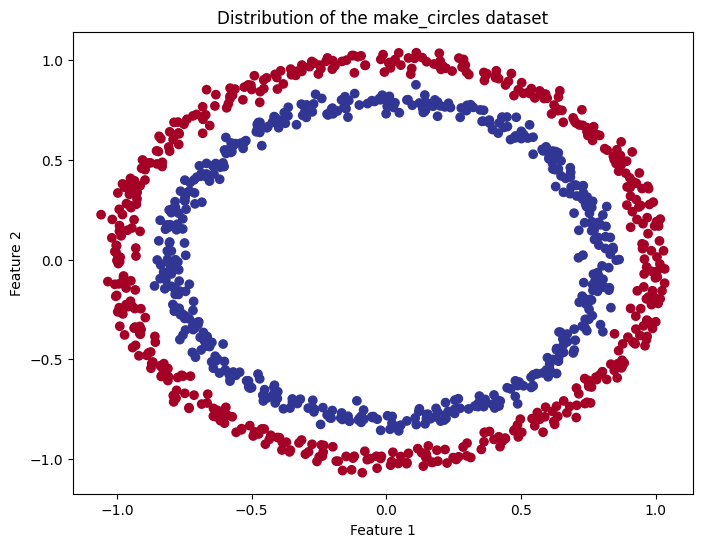

In [3]:
# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Distribution of the make_circles dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 3. Build a basic neural network model

We will now create a simple sequential model with a single dense layer, compile it using binary cross-entropy loss, and train it.

In [4]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# 1. Create the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid') # Output layer with sigmoid for binary classification
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])

# 3. Fit the model
history_1 = model_1.fit(X, y, epochs=100, verbose=0) # verbose=0 to suppress training output

# Evaluate the model
loss, accuracy = model_1.evaluate(X, y, verbose=0)
print(f"Model 1 - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

Model 1 - Loss: 0.6931, Accuracy: 0.4910


## 4. Improve the model

The poor performance of the previous model is due to the non-linearly separable nature of the `make_circles` dataset. A single-layer neural network with a sigmoid activation function can only learn linear decision boundaries. To improve the model, we will:

1.  **Add more layers and neurons**: This increases the model's capacity to learn complex patterns.
2.  **Increase training epochs**: Allowing the model to train for longer can help it converge to a better solution.
3.  **Try different optimizers**: Optimizers like Adam are often more effective than SGD for many tasks.

In [5]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# 1. Create a more complex model (2 layers)
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'), # Hidden layer with 10 neurons and ReLU activation
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer with 1 neuron and sigmoid activation
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(), # Using Adam optimizer
                metrics=['accuracy'])

# 3. Fit the model
history_2 = model_2.fit(X, y, epochs=200, verbose=0) # Increased epochs to 200

# Evaluate the model
loss_2, accuracy_2 = model_2.evaluate(X, y, verbose=0)
print(f"Model 2 - Loss: {loss_2:.4f}, Accuracy: {accuracy_2:.4f}")

Model 2 - Loss: 0.3565, Accuracy: 0.9910


## 5. Visualize the decision boundary

To better understand how our model is making predictions, we'll create a function `plot_decision_boundary()` that visualizes the areas where the model predicts class 0 or class 1. This will allow us to see the 'boundary' the model has learned.

In [6]:
def plot_decision_boundary(model, X, y):
    """
    Plots the decision boundary created by a model predicting on X.
    This function is inspired by:
    https://cs231n.github.io/neural-networks-case-study/
    """
    # Define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                           np.linspace(y_min, y_max, 100))

    # Create X values (we're going to predict on all of these)
    x_in = np.c_[xx.ravel(), yy.ravel()]

    # Make predictions using the trained model
    y_pred = model.predict(x_in)

    # Check for multi-class
    if len(y_pred[0]) > 1:
        print("doing multiclass classification")
        # We have to reshape our predictions to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


Now, let's use this function to visualize the decision boundary of our `model_1` (the basic model) and `model_2` (the improved model) to compare their performance visually.

Visualizing decision boundary for Model 1 (basic model):
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


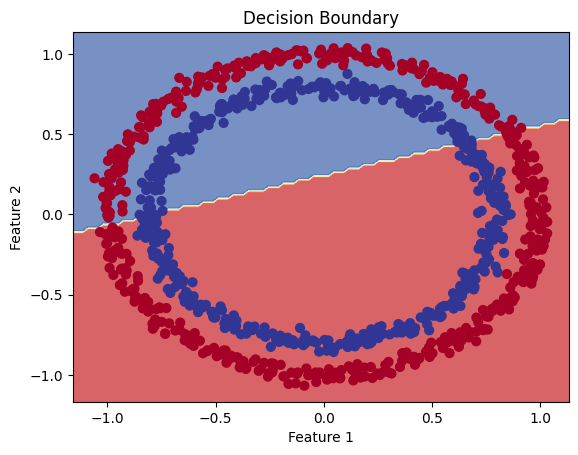

Visualizing decision boundary for Model 2 (improved model):
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


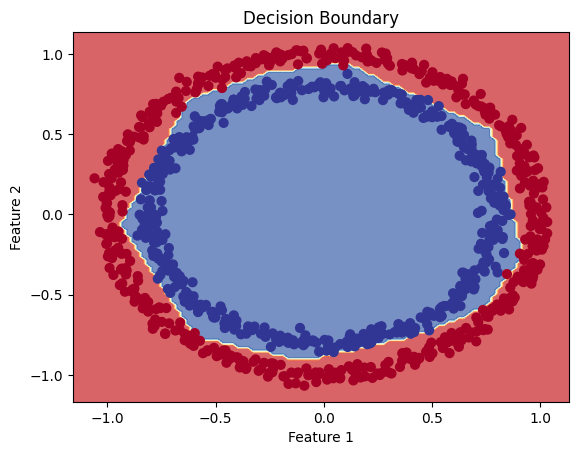

In [7]:
print("Visualizing decision boundary for Model 1 (basic model):")
plot_decision_boundary(model_1, X, y)

print("Visualizing decision boundary for Model 2 (improved model):")
plot_decision_boundary(model_2, X, y)

## 6. Incorporer des fonctions d'activation

Les fonctions d'activation introduisent une non-linéarité dans le réseau de neurones, lui permettant d'apprendre des relations plus complexes entre les entrées et les sorties. Sans fonctions d'activation, un réseau de neurones, même avec de nombreuses couches, se comporterait comme un seul modèle linéaire.

Nous allons explorer deux fonctions d'activation courantes : **ReLU** (Rectified Linear Unit) et **Sigmoïde**.

`model_2` utilisait déjà ReLU pour sa couche cachée et Sigmoïde pour sa couche de sortie. Nous allons maintenant créer un modèle `model_3` en expérimentant avec une configuration légèrement différente ou en explicitant le rôle des activations.

In [8]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# 1. Create a model with ReLU activation in the hidden layer
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),  # Hidden layer with ReLU
    tf.keras.layers.Dense(10, activation='relu'),  # Another hidden layer with ReLU
    tf.keras.layers.Dense(1, activation='sigmoid')   # Output layer with Sigmoid for binary classification
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), # Using Adam optimizer with a custom learning rate
                metrics=['accuracy'])

# 3. Fit the model
history_3 = model_3.fit(X, y, epochs=250, verbose=0) # Increased epochs and added another layer

# Evaluate the model
loss_3, accuracy_3 = model_3.evaluate(X, y, verbose=0)
print(f"Model 3 - Loss: {loss_3:.4f}, Accuracy: {accuracy_3:.4f}")

Model 3 - Loss: 0.0002, Accuracy: 1.0000


Let's visualize the decision boundary of `model_3` and compare it to the previous models.

Visualizing decision boundary for Model 3 (with ReLU hidden layers):
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


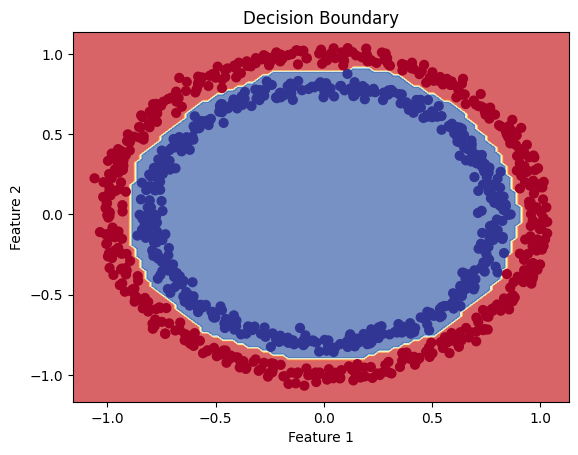

In [9]:
print("Visualizing decision boundary for Model 3 (with ReLU hidden layers):")
plot_decision_boundary(model_3, X, y)

## 7. Split the data into training and test sets

Until now, we've been training and evaluating our models on the entire dataset. This is not ideal for assessing how well a model will perform on *new, unseen data* (its generalization capability). To get a more realistic estimate of our model's performance, we need to split our data into a training set and a test set.

We will use 80% of the data for training and 20% for testing. Then, we will retrain our best model architecture (from `model_3`) on the training data and evaluate it on the test set.

In [10]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 20% for testing, 80% for training
                                                    random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 2)
Shape of y_train: (800,)
Shape of X_test: (200, 2)
Shape of y_test: (200,)


Now, let's create a new model (using the same architecture as `model_3`) and train it exclusively on the `X_train` and `y_train` data, then evaluate it on `X_test` and `y_test`.

In [11]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# Create a new model with the best architecture (from model_3)
model_final = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_final.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                    metrics=['accuracy'])

# Train the model on the training data
history_final = model_final.fit(X_train, y_train, epochs=250, verbose=0)

# Evaluate the model on the test data
loss_final, accuracy_final = model_final.evaluate(X_test, y_test, verbose=0)
print(f"Final Model - Loss on test set: {loss_final:.4f}, Accuracy on test set: {accuracy_final:.4f}")

Final Model - Loss on test set: 0.0039, Accuracy on test set: 1.0000


## 8. Évaluer et visualiser les performances du modèle final

Nous avons entraîné notre `model_final` sur l'ensemble d'entraînement et évalué ses performances sur l'ensemble de test. Nous allons maintenant visualiser les frontières de décision pour les deux ensembles afin de mieux comprendre le comportement du modèle et d'analyser sa capacité de généralisation.

Visualizing decision boundary for Final Model on TRAINING data:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
doing binary classification


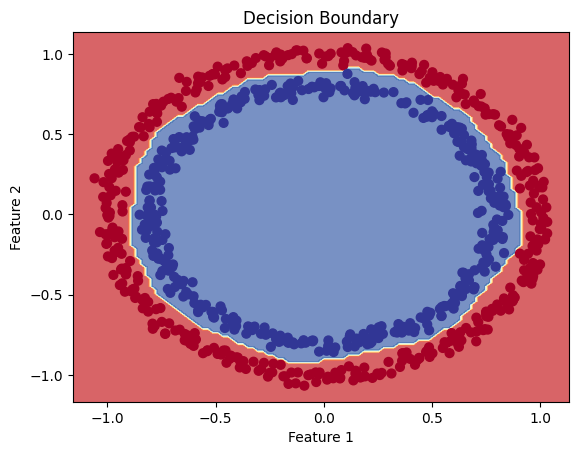

Visualizing decision boundary for Final Model on TEST data:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


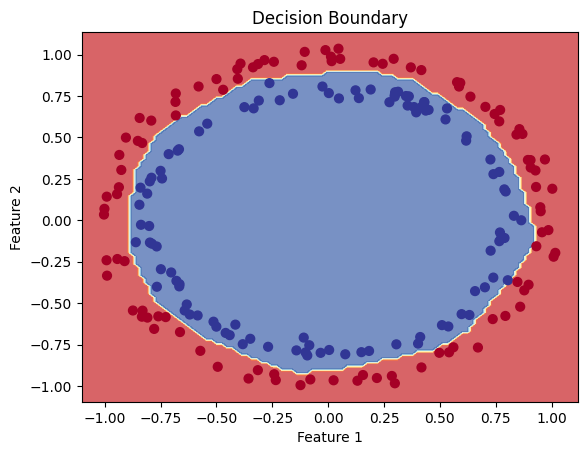

In [12]:
print("Visualizing decision boundary for Final Model on TRAINING data:")
plot_decision_boundary(model_final, X_train, y_train)

print("Visualizing decision boundary for Final Model on TEST data:")
plot_decision_boundary(model_final, X_test, y_test)

## 9. Résumer les points clés

Félicitations ! Vous avez parcouru un défi complet de classification avec des réseaux neuronaux dans TensorFlow. Voici un bref résumé des points clés que vous avez appris et mis en œuvre :

*   **Types de classification**: Vous avez compris les distinctions entre la classification binaire, multiclasse et multi-étiquettes, chacune avec ses propres applications et méthodes d'évaluation.
*   **Construction de modèles neuronaux**: Vous avez appris à construire des réseaux neuronaux séquentiels dans TensorFlow, en utilisant des couches `Dense`.
*   **Fonctions de perte et optimiseurs**: Vous avez expérimenté avec `BinaryCrossentropy` pour la perte et des optimiseurs comme `SGD` et `Adam`.
*   **Amélioration du modèle**: L'ajout de couches cachées, de neurones et l'augmentation des époques d'entraînement, combinés à l'utilisation d'optimiseurs plus avancés comme Adam, ont considérablement amélioré les performances sur un problème non linéaire.
*   **Fonctions d'activation**: L'importance des fonctions d'activation comme `ReLU` (pour l'introduction de la non-linéarité) et `Sigmoid` (pour la sortie de classification binaire) a été démontrée, permettant aux modèles d'apprendre des frontières de décision complexes.
*   **Visualisation des frontières de décision**: La fonction `plot_decision_boundary()` s'est avérée être un outil puissant pour visualiser intuitivement comment un modèle sépare les classes et évaluer visuellement ses prédictions.
*   **Division des données (entraînement/test)**: La scission du jeu de données en ensembles d'entraînement et de test est essentielle pour évaluer la capacité de généralisation d'un modèle et éviter le surapprentissage.

**Importance de la visualisation des données et du réglage des hyperparamètres**:

La visualisation initiale des données (`make_circles`) a instantanément révélé que le problème n'était pas linéaire, ce qui a justifié le besoin de réseaux neuronaux plus complexes. Les visualisations des frontières de décision à chaque étape (pour `model_1`, `model_2`, `model_3` et `model_final`) ont clairement montré l'impact des changements architecturaux et des hyperparamètres (nombre de couches, neurones, fonction d'activation, optimiseur, époques) sur la capacité du modèle à apprendre la séparation complexe des données.

Le réglage des hyperparamètres (nombre de couches, neurones, fonction d'activation, optimiseur, époques, taux d'apprentissage) est un processus itératif crucial. Chaque ajustement peut avoir un impact significatif sur la capacité du modèle à apprendre et à généraliser. Sans une exploration systématique et une visualisation, il serait difficile de diagnostiquer pourquoi un modèle sous-performe ou comment il pourrait être amélioré.